# 02 - Tarea 1: LeNet-5 y VGG-11 (con/sin Batch Normalization)
Entrenamiento desde cero de 4 variantes. Config: Adam, lr=1e-3, batch=64, 20 épocas, semilla 42, entrada 64×64. Se guarda el checkpoint con mejor accuracy de validación y con él se evalúa en TEST.

In [1]:
import sys, json, copy; sys.path.append('../src')
import pandas as pd  # importar pandas ANTES que torch: evita un crash del kernel en Windows
import torch, torch.nn as nn, matplotlib.pyplot as plt
from utils import set_seed, get_loaders, count_params, FIG_DIR, ROOT, SEED
from models import build_model
from train import fit, evaluate

RES_DIR = ROOT/'results'; CKPT_DIR = RES_DIR/'checkpoints'; CKPT_DIR.mkdir(parents=True, exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device, torch.cuda.get_device_name(0) if device.type == 'cuda' else '')
EPOCHS, LR, BS = 20, 1e-3, 64
train_loader, val_loader, test_loader = get_loaders(img_size=64, batch_size=BS)

cuda NVIDIA GeForce RTX 4050 Laptop GPU


## Entrenamiento de las 4 variantes

In [2]:
def run_and_eval(name, use_bn, lr=LR, epochs=EPOCHS, tag=None):
    tag = tag or f"{name}{'_bn' if use_bn else ''}"
    set_seed(SEED)
    model = build_model(name, use_bn).to(device)
    n_params = count_params(model)
    print(f"== {tag} | params: {n_params:,}")
    ckpt = CKPT_DIR/f'{tag}_best.pt'
    hist = fit(model, train_loader, val_loader, epochs, lr, device, ckpt_path=ckpt)
    model.load_state_dict(torch.load(ckpt))   # mejor época según validación
    tl, ta = evaluate(model, test_loader, nn.CrossEntropyLoss(), device)
    return dict(tag=tag, params=n_params, hist=hist, test_loss=tl, test_acc=ta)

In [3]:
results = {}
for name, bn in [('lenet', False), ('lenet', True), ('vgg11', False), ('vgg11', True)]:
    r = run_and_eval(name, bn); results[r['tag']] = r
    print(f"-> test acc {r['test_acc']:.4f}\n")

== lenet | params: 337,976


ep 01/20 | train 1.3010/0.3664 | val 1.1557/0.4612 | 1.0s


ep 02/20 | train 1.0577/0.5149 | val 0.9995/0.5382 | 0.7s


ep 03/20 | train 0.9178/0.5867 | val 0.8406/0.6078 | 1.3s


ep 04/20 | train 0.7172/0.6734 | val 0.8903/0.5870 | 1.3s


...

ep 17/20 | train 0.1055/0.9620 | val 0.3679/0.8862 | 3.4s


ep 18/20 | train 0.1480/0.9547 | val 0.0834/0.9719 | 3.3s


ep 19/20 | train 0.1217/0.9553 | val 0.1201/0.9705 | 3.4s


ep 20/20 | train 0.0463/0.9831 | val 0.0649/0.9772 | 3.4s


-> test acc 0.8416



## Tabla resumen

In [4]:
rows = []
for t, r in results.items():
    h = r['hist']
    rows.append(dict(Modelo=t, Parametros=r['params'],
                     **{'Tiempo/epoca (s)': round(sum(h['epoch_time'][1:])/(len(h['epoch_time'])-1), 2),
                        'Mejor val acc': round(max(h['val_acc']), 4),
                        'Test acc': round(r['test_acc'], 4),
                        'Epocas a 80% val': next((i+1 for i, a in enumerate(h['val_acc']) if a >= 0.8), None)}))
summary = pd.DataFrame(rows); summary.to_csv(RES_DIR/'t1_resumen.csv', index=False)
json.dump({t: dict(params=r['params'], test_acc=r['test_acc'], test_loss=r['test_loss'], hist=r['hist'])
           for t, r in results.items()}, open(RES_DIR/'t1_resultados.json', 'w'))
summary

,Modelo,Parametros,Tiempo/epoca (s),Mejor val acc,Test acc,Epocas a 80% val
0,lenet,337976,1.39,0.9645,0.7254,5
1,lenet_bn,337998,1.57,0.9672,0.6647,4
2,vgg11,3095748,2.82,0.9846,0.8593,5
3,vgg11_bn,3097124,3.21,0.9839,0.8416,9


## Curvas de pérdida y accuracy

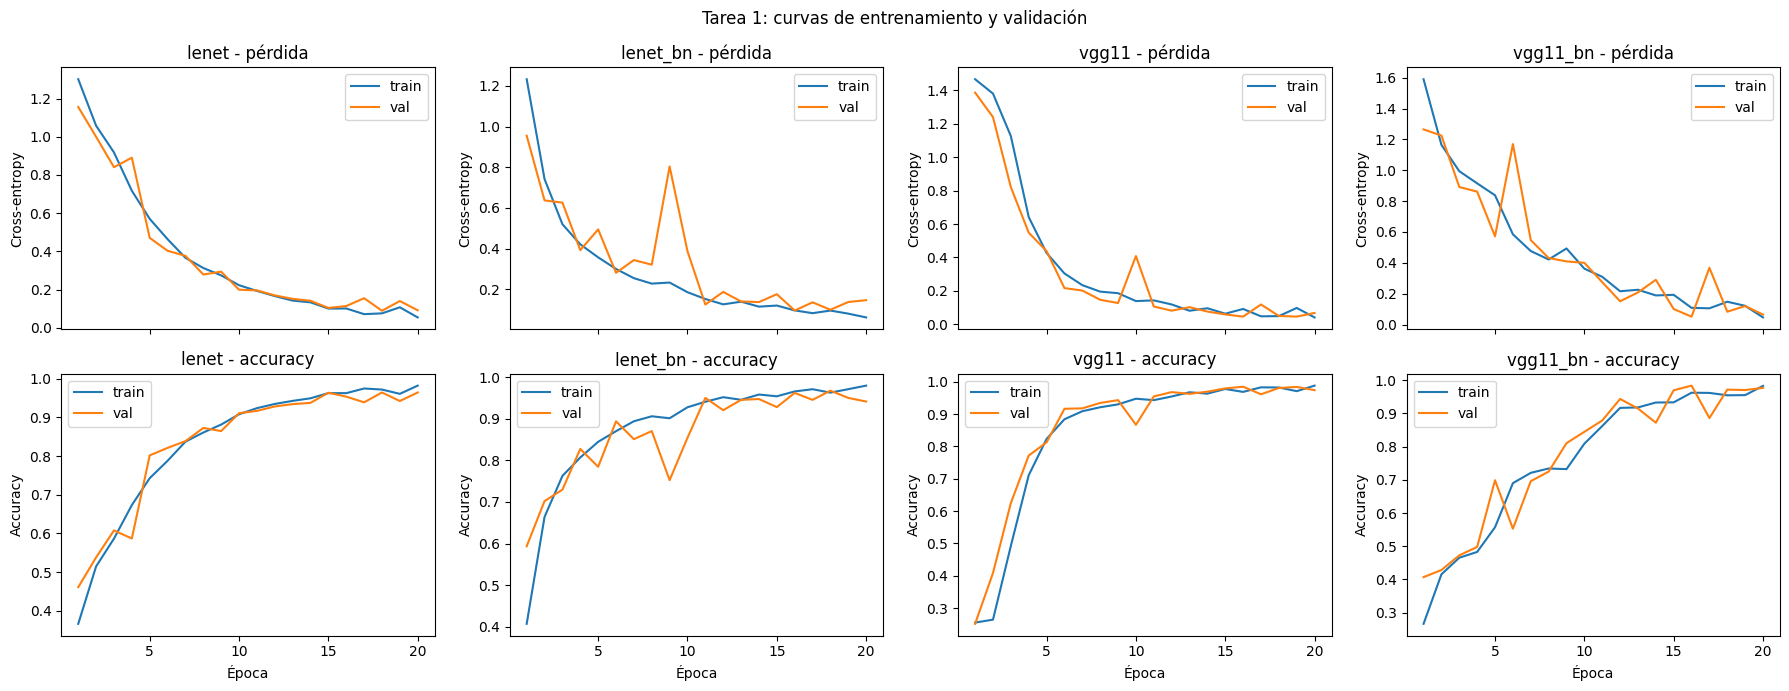

In [5]:
fig, axs = plt.subplots(2, 4, figsize=(18, 7), sharex=True)
for j, (t, r) in enumerate(results.items()):
    h = r['hist']; ep = range(1, len(h['train_loss'])+1)
    axs[0, j].plot(ep, h['train_loss'], label='train'); axs[0, j].plot(ep, h['val_loss'], label='val')
    axs[0, j].set_title(f'{t} - pérdida'); axs[0, j].set_ylabel('Cross-entropy'); axs[0, j].legend()
    axs[1, j].plot(ep, h['train_acc'], label='train'); axs[1, j].plot(ep, h['val_acc'], label='val')
    axs[1, j].set_title(f'{t} - accuracy'); axs[1, j].set_ylabel('Accuracy'); axs[1, j].set_xlabel('Época'); axs[1, j].legend()
fig.suptitle('Tarea 1: curvas de entrenamiento y validación'); plt.tight_layout()
plt.savefig(FIG_DIR/'t1_curvas.png', dpi=150); plt.show()